Svolgi i punti uno alla volta e produci un documento di testo o pdf in cui commenti il codice e spieghi ciò che hai fatto. Consegna anche l'Rscript (il file.R). Puoi consegnare anche solo quest'ultimo, scrivendo i commenti sopra le righe di codice e ovviamente il punto corrispondente. 
Non preoccuparti se non sai come risolvere qualche punto: provaci, riprovaci e male che vada consegna anche solo il codice col tentativo. Altre considerazioni e analisi fuori dagli schemi sono assolutamente ben accette!

Usa il manuale integrato di R utilizzando la funzione "help(nomefunzione)" oppure "?nomefunzione", per capire come usare tutti i vari argomenti… e non dimenticarti che Google è tuo amico, anzi, è pieno di amici!
Non c'è alcun limite imposto per l'utilizzo di R e la fantasia! Se sei uno smanettone come me, divertiti a cercare pacchetti e funzioni che possano agevolarti il lavoro.
 Se non sei un principiante della programmazione, sbizzarrisciti pure! 
Io ti lascio comunque qualche file utile e ti consiglio di darci almeno un'occhiata prima di partire 😉

**1)** Importa il dataset "Real Estate Texas.csv", contenente dei dati riguardanti le vendite di immobili in Texas. Le variabili del dataset sono:

city: città.  
year: anno di riferimento.  
month: mese di riferimento.  
sales: numero totale di vendite.  
volume: valore totale delle vendite in milioni di dollari.  
median_price: prezzo mediano di vendita in dollari.  
listings: numero totale di annunci attivi.  
months_inventory: quantità di tempo necessaria per vendere tutte le inserzioni correnti al ritmo attuale delle vendite, espresso in mesi.   |

In [7]:
df_house <- read.csv(file = "Real Estate Texas.csv")
head(df_house)

attach(df_house)

,city,year,month,sales,volume,median_price,listings,months_inventory
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>
1,Beaumont,2010,1,83,14.162,163800,1533,9.5
2,Beaumont,2010,2,108,17.690,138200,1586,10.0
3,Beaumont,2010,3,182,28.701,122400,1689,10.6
4,Beaumont,2010,4,200,26.819,123200,1708,10.6
5,Beaumont,2010,5,202,28.833,123100,1771,10.9
6,Beaumont,2010,6,189,27.219,122800,1803,11.1


**2)** Indica il tipo di variabili contenute nel dataset.

> __city__, e' una variabile tipo char che identifica la citta' sotto analisi.  
> __year__, variabile int, indica l'anno considerato.  
> __month__, variabile int, indica il mese.  
> __sales__, variabile int, il numero di vendite effettuate per quella citta, in quell'anno, mese.  
> __volume__, variabile double, il valore comulative delle vendite per quella citta, in quell'anno, mese, in Mln di $.   
> __median_price__, variabile double, il valore mediano del prezzo di vendita per le transazioni effettuate per quella citta, in quell'anno, mese    
> listing, variabile int, il numero di annunci per quella citta, in quell'anno, mese.  
> __months_inventor__, variaible double, il numero di mesi necessario per risolvere un annuncio considerato il ritmo attuale delle vendite.   

**3)** Calcola Indici di posizione, variabilità e forma per tutte le variabili per le quali ha senso farlo, per le altre crea una distribuzione di frequenza. Commenta tutto brevemente.

In [70]:
library(moments)

out.pos.idx <- function(column){

    var_name <- deparse(substitute(column))
    
    col.n = length(column)
    col.mu = round(mean(column), 2)
    col.median = round(median(column),2)
    col.iqr = round(IQR(column),2)
    col.range = I(list(range(column)))
    col.quantiles = I(list(quantile(column)))
    col.sigma2 = signif(sum((column-col.mu)^2)/col.n ,2)
    col.sigma = signif(sqrt(col.sigma2),2)
    col.cv = round(col.sigma/ col.mu,2)
    col.skew = round(skewness(column),2)
    col.kurt = round(kurtosis(column) -3,2)

     df <- data.frame(
        col.n , 
        col.mu , 
        col.median , 
        col.iqr , 
        col.range , 
        col.quantiles, 
        col.sigma2, 
        col.sigma , 
        col.cv , 
        col.skew , 
        col.kurt
    )
    row.names(df) <- var_name
    return(df)
}

v1 <- out.pos.idx(sales) 
v2 <- out.pos.idx(volume)
v3 <- out.pos.idx(median_price)
v4 <- out.pos.idx(listings)
v5 <- out.pos.idx(months_inventory)

rbind(v1,v2,v3,v4,v5)

,col.n,col.mu,col.median,col.iqr,col.range,col.quantiles,col.sigma2,col.sigma,col.cv,col.skew,col.kurt
,<int>,<dbl>,<dbl>,<dbl>,<I<list>>,<I<list>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sales,240,192.29,175.50,120.00,"79, 423","79, 127,....",6.3e+03,79.0,0.41,0.72,-0.31
volume,240,31.01,27.06,23.23,"8.166, 8....","8.166, 1....",2.8e+02,17.0,0.55,0.88,0.18
median_price,240,132665.42,134500.00,32750.00,"73800, 1....","73800, 1....",5.1e+08,23000.0,0.17,-0.36,-0.62
listings,240,1738.02,1618.50,1029.50,"743, 3296","743, 102....",5.6e+05,750.0,0.43,0.65,-0.79
months_inventory,240,9.19,8.95,3.15,"3.4, 14.9","3.4, 7.8....",5.3e+00,2.3,0.25,0.04,-0.17


> Ciascuna variabile ha una sua distribuzione all'interno del dataset per cui ho calcolato tutti gli > indici di posizione, di forma e la variabilità per ciascuna di esse.   
> Non ha ovviamente senso calcolare tali indici per la variabile city, year e month in quanto rappresentano solo il timeframe e la città considerata per la raccolta dati. Non trovo il senso di fare grafici di frequenza per queste tre colonne in quanto non darebbero nessuna informazione utile a questo punto dell'analisi.   
>     
> Per il calcolo degli indici ho costruito una piccola funzione che calcola tutti i valori per una possibile ottenere un oggetto lista facilmente consultabile e il cui ouput visivo sia anche informativo.
> 
> In ogni caso visualizzo la distribuzione di frequenze per le varie colonne qui di seguito.


The downloaded binary packages are in
	/var/folders/p3/80498z8x71z1_xfxtnstpxkc0000gn/T//RtmpkTXdkj/downloaded_packages


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


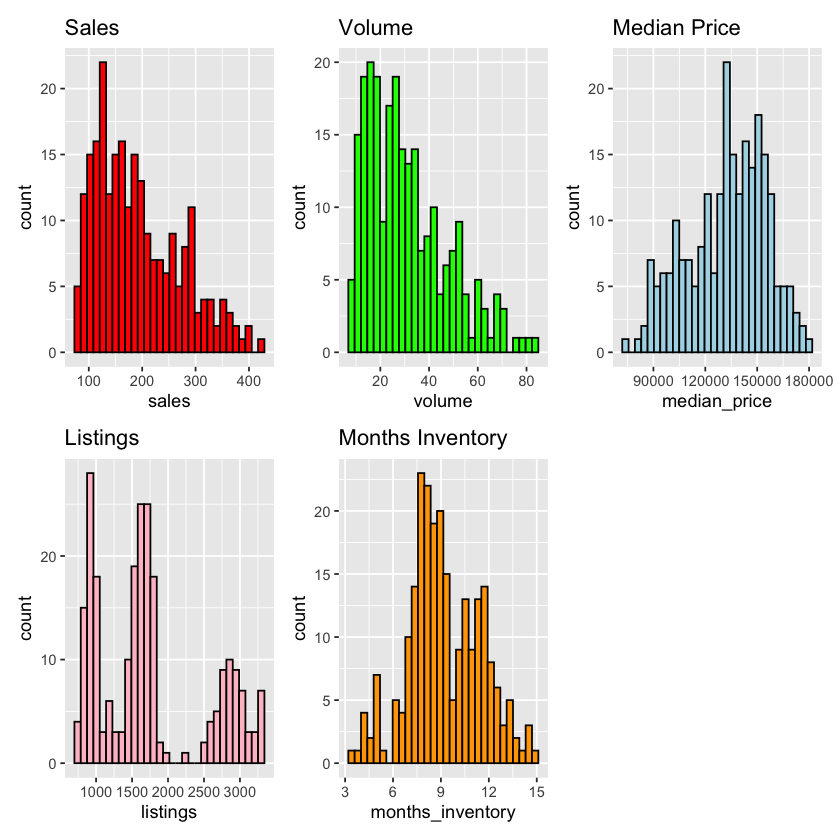

In [ ]:
#install.packages("patchwork")
library(patchwork)
library(ggplot2)

# Crea i singoli grafici
p1 <- ggplot(df_house) + geom_histogram(aes(x = sales), col = "black", fill = "red") + ggtitle("Sales")
p2 <- ggplot(df_house) + geom_histogram(aes(x = volume), col = "black", fill = "green") + ggtitle("Volume")
p3 <- ggplot(df_house) + geom_histogram(aes(x = median_price), col = "black", fill = "lightblue") + ggtitle("Median Price")
p4 <- ggplot(df_house) + geom_histogram(aes(x = listings), col = "black", fill = "pink") + ggtitle("Listings")
p5 <- ggplot(df_house) + geom_histogram(aes(x = months_inventory), col = "black", fill = "orange") + ggtitle("Months Inventory")

p1 + p2 + p3 + p4 + p5 + plot_layout(nrow = 2, ncol = 3)

**4)** Qual è la variabile con variabilità più elevata? Come ci sei arrivato? E quale quella più asimmetrica?

>Il grafico rappresenta bene i valori degli indici di forma estratti in tabella. __Sales__ e __Volume__ hanno un disribuzione asimmetrica piu' accentuata con una lunga coda a destra, ben rappresentato dalle loro skewness alte.   
> I valori di media maggiori da quelli delle mediana suggeriscono la stessa distribuzione dei dati. Il confronto dei valori di CV tabella confermano __Volume__ come la variabile con maggiore variabilita', seguito da __listings__, che e' sicuramente la variabile piu' eterogenea con una distribuzione bi/multimodale, e da __Sales__.    
>__Median_price__ invece e' meno assimetrica delle variabili precedenti, cosi' come __Months_Inventory__, che tende ad una distribuzione gaussiana, come suggeriscono i valori di >skewness e sigma particolarmente bassi. 


**5)** Dividi una delle variabili quantitative in classi, scegli tu quale e come, costruisci la distribuzione di frequenze, il grafico a barre corrispondente e infine calcola l'indice di Gini.

,ni,fi,Ni,Fi
,<dbl>,<dbl>,<dbl>,<dbl>
"(8.09,11.9]",19,0.0791667,19,0.079167
"(11.9,15.7]",28,0.1166667,47,0.195833
"(15.7,19.5]",27,0.1125000,74,0.308333
"(19.5,23.2]",19,0.0791667,93,0.387500
"(23.2,27]",27,0.1125000,120,0.500000
"(27,30.8]",18,0.0750000,138,0.575000
"(30.8,34.5]",17,0.0708333,155,0.645833
"(34.5,38.3]",17,0.0708333,172,0.716667
"(38.3,42.1]",12,0.0500000,184,0.766667


Don't know how to automatically pick scale for object of type <table>.
Defaulting to continuous.


[1] 0.92306

[1] 0.97164

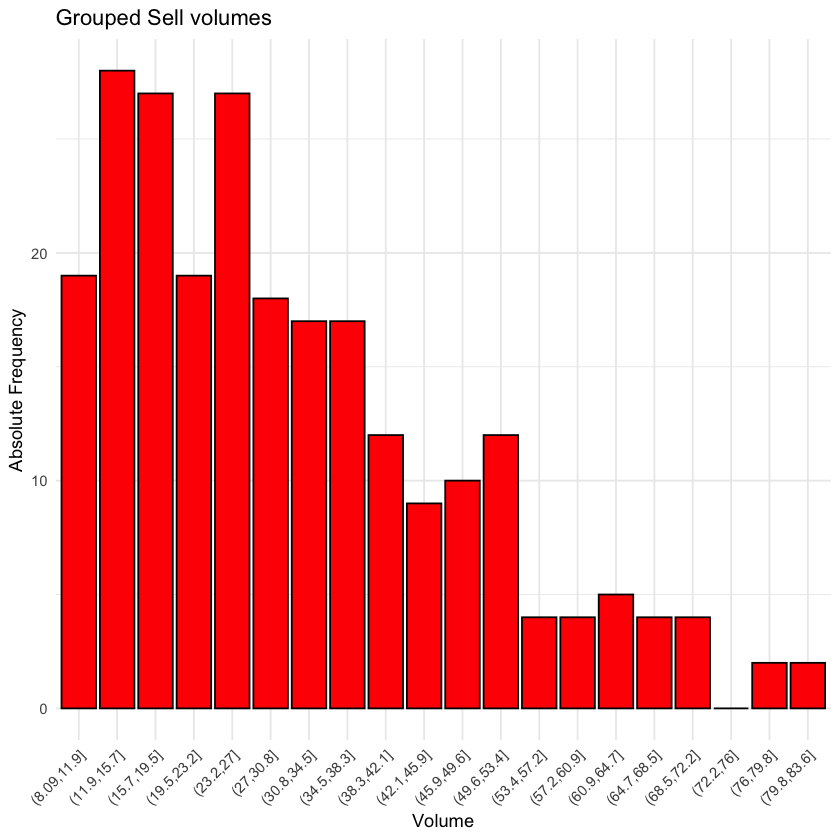

In [178]:
# df_house$volume_cl <- 
vol.cl <- cut(volume, 20);

n <- length(vol.cl)
ni <- table(vol.cl)
fi <- ni/n
Ni <- cumsum(ni)
Fi <- cumsum(fi)

vol.cl.tab <- as.data.frame(cbind(ni, fi, Ni, Fi))
vol.cl.tab

ggplot() +
    geom_col(aes(x=factor(row.names(vol.cl.tab), levels = row.names(vol.cl.tab)), y = ni), fill = "red", col="black") +
    labs(x = "Volume", y = "Absolute Frequency",title = "Grouped Sell volumes") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

#gini index
g <- 1 - sum(fi^2)
J <- length(ni)
g_norm <- g/((J-1)/J)
g; g_norm

> Gini index revealed a large heterogeneity for the given dataset as it is closed to 1. By varying the number of items it is also interesting to note how the gini index increase as the number of classes increses, as expected from the mathematical definition.

**6)** Indovina l'indice di gini per la variabile city.

> As there are exactly 60 entries per city the Gini index will be 1.

**7)** Qual è la probabilità che presa una riga a caso di questo dataset essa riporti la città "Beaumont"? E la probabilità che riporti il mese di Luglio? E la probabilità che riporti il mese di dicembre 2012?

> P(Beaumont) = n of Beaumont rows / n tot rows = 60/240 = 1/4.   
> P(Luglio) = n of months July / n tot rows = 20/240 =  1/12,   
> P(Dic 2012) = P(12 ∩ 2012) = 1/12 × 1/5 = 1/60.   
> oppure.  
> P(Dic 2012) = n of entries Dec 2012 / n tot rows = 4/240 = 1/60.  
> 
> Non c'e' bisogno di far girare nessun codice in questo caso visto che il dataset e' distribuito omogeneamente tra __city__, __month__ e __year__.
> Se proprio si vuole verificare quanto scritto basta vedere la tabelle delle frequenze per __month__,  __year__ e la tabella delle frequenze congiunta per [__month__ , __year__], che metto qui di seguito

In [188]:
qual.freq.table <- function(variable){
    n <- length(variable)
    ni <- table(variable)
    fi <- ni/n
    Ni <- cumsum(ni)
    Fi <- cumsum(fi)

   cl.tab  <- as.data.frame(cbind(ni, fi, Ni, Fi))
   return(cl.tab)
}

qual.freq.table(city)
qual.freq.table(month)
table(year, month)

,ni,fi,Ni,Fi
,<dbl>,<dbl>,<dbl>,<dbl>
Beaumont,60,0.25,60,0.25
Bryan-College Station,60,0.25,120,0.50
Tyler,60,0.25,180,0.75
Wichita Falls,60,0.25,240,1.00


,ni,fi,Ni,Fi
,<dbl>,<dbl>,<dbl>,<dbl>
1,20,0.083333,20,0.083333
2,20,0.083333,40,0.166667
3,20,0.083333,60,0.250000
4,20,0.083333,80,0.333333
5,20,0.083333,100,0.416667
6,20,0.083333,120,0.500000
7,20,0.083333,140,0.583333
8,20,0.083333,160,0.666667
9,20,0.083333,180,0.750000


      month
year   1 2 3 4 5 6 7 8 9 10 11 12
  2010 4 4 4 4 4 4 4 4 4  4  4  4
  2011 4 4 4 4 4 4 4 4 4  4  4  4
  2012 4 4 4 4 4 4 4 4 4  4  4  4
  2013 4 4 4 4 4 4 4 4 4  4  4  4
  2014 4 4 4 4 4 4 4 4 4  4  4  4

**8)** Esiste una colonna col prezzo mediano, creane una che indica invece il prezzo medio, utilizzando le altre variabili che hai a disposizione

In [192]:
head(df_house)
df_house$mean_price <- volume*1000000/sales
head(df_house)

,city,year,month,sales,volume,median_price,listings,months_inventory
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>
1,Beaumont,2010,1,83,14.162,163800,1533,9.5
2,Beaumont,2010,2,108,17.690,138200,1586,10.0
3,Beaumont,2010,3,182,28.701,122400,1689,10.6
4,Beaumont,2010,4,200,26.819,123200,1708,10.6
5,Beaumont,2010,5,202,28.833,123100,1771,10.9
6,Beaumont,2010,6,189,27.219,122800,1803,11.1


,city,year,month,sales,volume,median_price,listings,months_inventory,mean_price
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,Beaumont,2010,1,83,14.162,163800,1533,9.5,170627
2,Beaumont,2010,2,108,17.690,138200,1586,10.0,163796
3,Beaumont,2010,3,182,28.701,122400,1689,10.6,157698
4,Beaumont,2010,4,200,26.819,123200,1708,10.6,134095
5,Beaumont,2010,5,202,28.833,123100,1771,10.9,142738
6,Beaumont,2010,6,189,27.219,122800,1803,11.1,144016


> Possiamo definire un prezzo medio di vendita per ogni mese dividendo il totale del volume di vendita (volume), in milioni di $, per il numero di vendite effettaute (sales). L'analisi delle prime righe del dataset conferma che median e mean price sono infatti vicini tra loro

**9)** Prova a creare un'altra colonna che dia un'idea di "efficacia" degli annunci di vendita. Riesci a fare qualche considerazione?

In [ ]:
eff_idx <- volume/months_inventory
eff_idx_norm <- (eff_idx-min(eff_idx)) / (max(eff_idx) - min(eff_idx))
df_house$eff_idx<- eff_idx
df_house$eff_idx_norm<- eff_idx_norm

qual.freq.table(cut(df_house$eff_idx, 10))
qual.freq.table(cut(df_house$eff_idx_norm, 10))
head(df_house)

,ni,fi,Ni,Fi
,<dbl>,<dbl>,<dbl>,<dbl>
"(1.03,2.98]",133,0.5541667,133,0.55417
"(2.98,4.91]",62,0.2583333,195,0.81250
"(4.91,6.85]",22,0.0916667,217,0.90417
"(6.85,8.78]",8,0.0333333,225,0.93750
"(8.78,10.7]",7,0.0291667,232,0.96667
"(10.7,12.6]",4,0.0166667,236,0.98333
"(12.6,14.6]",0,0.0000000,236,0.98333
"(14.6,16.5]",2,0.0083333,238,0.99167
"(16.5,18.4]",1,0.0041667,239,0.99583


,ni,fi,Ni,Fi
,<dbl>,<dbl>,<dbl>,<dbl>
"(-0.001,0.1]",133,0.5541667,133,0.55417
"(0.1,0.2]",62,0.2583333,195,0.81250
"(0.2,0.3]",22,0.0916667,217,0.90417
"(0.3,0.4]",8,0.0333333,225,0.93750
"(0.4,0.5]",7,0.0291667,232,0.96667
"(0.5,0.6]",4,0.0166667,236,0.98333
"(0.6,0.7]",0,0.0000000,236,0.98333
"(0.7,0.8]",2,0.0083333,238,0.99167
"(0.8,0.9]",1,0.0041667,239,0.99583


,city,year,month,sales,volume,median_price,listings,months_inventory,mean_price,eff_idx,eff_idx_norm
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,Beaumont,2010,1,83,14.162,163800,1533,9.5,170627,1.4907,0.022959
2,Beaumont,2010,2,108,17.690,138200,1586,10.0,163796,1.7690,0.037354
3,Beaumont,2010,3,182,28.701,122400,1689,10.6,157698,2.7076,0.085912
4,Beaumont,2010,4,200,26.819,123200,1708,10.6,134095,2.5301,0.076727
5,Beaumont,2010,5,202,28.833,123100,1771,10.9,142738,2.6452,0.082684
6,Beaumont,2010,6,189,27.219,122800,1803,11.1,144016,2.4522,0.072696


> Per ottenere una sorta di efficiency_index consideriamo la variabile __months_inventory__ per la quale minore sara' il valore di questa variabile piu' velocemente gli annunci vengono venduti.   
> Dividendo quindi il volume di vendita (__volume__) per questa variabile, è possibile ottenere una sorta di velocità di vendita per Mln di $ per mese.      

$$ eff.idx = \frac{volume}{months\_inventory} $$

> Dello stesso indice calcolo poi un valore normalizzato per il min e il max dello stesso all'interno dello stesso dataset, in modo tale che questo sia compreso tra [0,1].  

$$ eff.idx.norm = \frac{eff.idx-min(eff.idx)}{range(eff.idx)} $$

> E' interessante notare come questi indici rivelino una bassa efficienza per gli annunci immobiliari visto la distribuzione delle frequenze dei dati.   
> Di seguito riporto qualche indice di posizone e grafico per meglio visualizzare la situazione.

,col.n,col.mu,col.median,col.iqr,col.range,col.quantiles,col.sigma2,col.sigma,col.cv,col.skew,col.kurt
,<int>,<dbl>,<dbl>,<dbl>,<I<list>>,<I<list>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
eff_idx,240,3.69,2.77,2.35,1.046923....,1.046923....,8.000,2.80,0.76,2.62,8.7
eff_idx_norm,240,0.14,0.09,0.12,"0, 1","0, 0.047....",0.022,0.15,1.07,2.62,8.7


[[1]]
     0%     25%     50%     75%    100% 
 1.0469  1.9724  2.7737  4.3175 20.3773 


[[1]]
      0%      25%      50%      75%     100% 
0.000000 0.047879 0.089331 0.169194 1.000000 


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


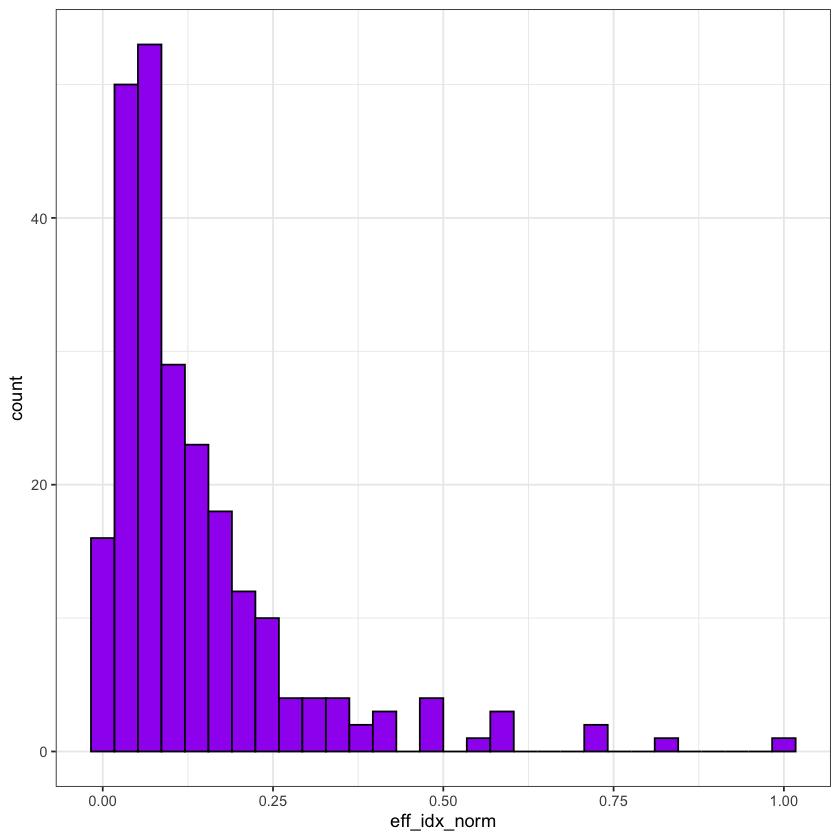

In [230]:
t1<-out.pos.idx(eff_idx)
t2<-out.pos.idx(eff_idx_norm)

rbind(t1,t2)
t1$col.quantiles
t2$col.quantiles

ggplot() +
    geom_histogram(aes(x=eff_idx_norm), fill = "purple", col = "black")+
    theme_bw()

> Dall'analisi si evince chiaramente come solo meno del 25% abbia un indice di efficienza normalizzato superiore a 0.2, aspetto confermato anche dall'istogramma dell'indice normalizzato che presenta una grossa concentrazione di dati sotto 0.25 di indice di efficienza con una lunga coda a sinistra

**10)** Prova a creare dei summary(), o semplicemente media e deviazione standard, di alcune variabili a tua scelta, condizionatamente alla città, agli anni e ai mesi. Puoi utilizzare il linguaggio R di base oppure essere un vero Pro con il pacchetto dplyr. Ti lascio un suggerimento in pseudocodice, oltre al cheatsheet nel materiale:

  dati %>%
  group_by(una o più variabili di raggruppamento) %>%
  summarise(nomecolonna1=funzione1(variabile da sintetizzare),
  nomecolonna2=funzione2(variabile da sintetizzare))

Sfruttando questa notazione puoi creare anche dei grafici super!

Da qui in poi utilizza ggplot2 per creare grafici fantastici! 
Ma non fermarti alla semplice soluzione del quesito, prova un po' a personalizzare i grafici utilizzando temi, colori e annotazioni, e aggiustando i vari elementi come le etichette, gli assi e la legenda.
Consiglio: Stai attento quando specifichi le variabili month e year tra le estetiche, potrebbe essere necessario considerarle come fattori.

**1)** Utilizza i boxplot per confrontare la distribuzione del prezzo mediano delle case tra le varie città. Commenta il risultato

**2)** Utilizza i boxplot o qualche variante per confrontare la distribuzione del valore totale delle vendite tra le varie città ma anche tra i vari anni. Qualche considerazione da fare?

**3)** Usa un grafico a barre sovrapposte per confrontare il totale delle vendite nei vari mesi, sempre considerando le città. Prova a commentare ciò che viene fuori. Già che ci sei prova anche il grafico a barre normalizzato. Consiglio: Stai attento alla differenza tra geom_bar() e geom_col(). PRO LEVEL: cerca un modo intelligente per inserire ANCHE la variabile Year allo stesso blocco di codice, senza però creare accrocchi nel grafico.

**4)** Prova a creare un line chart di una variabile a tua scelta per fare confronti commentati fra città e periodi storici. Ti avviso che probabilmente all'inizio ti verranno fuori linee storte e poco chiare, ma non demordere. Consigli: Prova inserendo una variabile per volta. Prova a usare variabili esterne al dataset, tipo vettori creati da te appositamente.

Se non riesci proprio a venirne a capo inizia lavorando su dataset ridotti, ad esempio prendendo in considerazione un solo anno o una sola città. Aiutati con il pacchetto dplyr:
dati2014 <- filter(dati, year==2014)
dati_Beaumont <- filter(dati, city=="Beaumont")